# Monte Carlo v4

## Part 1, Building the Experiment

This research starts from a clear premise: design decisions for US offshore wind development should not be evaluated against a single future assumed as certain. They need to be examined against a wide range of plausible futures, because the occupation of marine space, the technologies adopted, the installed power density, and the aerodynamic interactions between wind farms still carry relevant uncertainties.

The risk of making non-optimal decisions can be mitigated by evaluating thousands of possibilities for offshore development and its associated hybrid systems. The proposal here is to use a Monte Carlo simulation (Harrison, 2010) as the mechanism to generate these many possible worlds: different layouts, different rated powers, different power densities across farms, different turbine counts, and different intensities of marine-space occupation. Uncertainty then needs to be propagated through the analysis and, later, through optimization, so it becomes possible to evaluate the risk of a design decision turning out to be inadequate once the future actually happens.

That is the starting point of this work. The goal is not to claim that one specific scenario will be the future of US offshore wind, but to recognize that the future is still open, infinite possibilities that nobody can say for certain, and to build a computational structure able to answer, quantitatively: how do wake losses and the production of a farm built today in this region change and suffer as the offshore region develops in different ways?

As offshore development grows, the question stops being just "where is the wind?" and becomes "how does the collective use of marine space change efficiency, risk, and the quality of investment decisions?"

The implementation here turns that direction into an operational process: a reproducible set of modules that generates scenarios, calculates wake interactions with PyWake, logs the results, and prepares the information needed for later risk analyses.

The study produces hundreds of possible offshore development configurations. The current implementation turns that idea into `trials`. Each `trial` is one complete, coherent realization of the future between 2026 and 2050.

Each `trial`, one run where the scenario grows, combines random choices that are still controlled and traceable. One simulated future can have a specific sequence of farms entering operation, a specific mix of turbines, a particular occupation density, and a small variation in the wind resource. Another `trial` can have a completely different history. By running many trials, the study produces a distribution of results, not just a single answer. An important point: since each `trial` is deterministic, it is reproducible from the seed used to generate it.

## 0. Imports & Constants

`requirements.txt` lists `pywake` instead of `py_wake` (installs the wrong package on PyPI) and is missing a few libraries the pipeline needs. This cell installs what's actually missing, on top of `requirements.txt`.

In [1]:
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                 "py_wake", "windIO", "shapely", "geopandas", "utm", "geojson", "pandas", "IPython"], check=True)

CompletedProcess(args=['/opt/anaconda3/envs/wesl_jul_31/bin/python', '-m', 'pip', 'install', '-q', 'py_wake', 'windIO', 'shapely', 'geopandas', 'utm', 'geojson', 'pandas', 'IPython'], returncode=0)

In [2]:
import inspect
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import windIO
from pyproj import Transformer
from shapely.geometry import shape
from shapely.ops import unary_union, transform as shp_transform

MC_V4_DIR = Path("..") / ".."  # notebooks/Final_Project -> Monte_Carlo_v4
sys.path.insert(0, str(MC_V4_DIR))
sys.path.insert(0, str(MC_V4_DIR / ".." / "Layout_Generation"))
import mosaic

import settings
import cluster
import layout
import scenarios
import turbines
import timeline
import spacing
import climate
import grid_fill
import aep
import wake_models
import orchestrator
from instrumentation import Logger

/opt/anaconda3/envs/wesl_jul_31/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_DIR = settings.DATA_DIR
STATES_PATH = DATA_DIR.parent / "Create_Graphs" / "data" / "us_states.json"
ETOPO_PATH = DATA_DIR.parent / "Create_Graphs" / "data" / "etopo_east_coast_hires.nc"  # basemap only, NOT what
                                                                                        # layout.py's eligibility
                                                                                        # mask actually uses
                                                                                        # (that's bathymetry_us.nc)
SLA_PATH = DATA_DIR.parent / "WindFarms" / "US_Cluster" / "Data" / "Federal_State_Boundary_SLA.geojson"

In [4]:
SEED = 9
COLOR_LAND = "#ece9e2"
COLOR_LEASE = "#2b2a27"
MAP_FIGSIZE = (8, 8)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

In [5]:
# reuses layout.py's own base grid, so it can't drift from the real eligibility mask
GX, GY = layout.BASE_GRID["GX"], layout.BASE_GRID["GY"]
x0, y0, res = layout.BASE_GRID["x0"], layout.BASE_GRID["y0"], layout.BASE_GRID["res"]
EXTENT_KM = [GX.min() / 1000, GX.max() / 1000, GY.min() / 1000, GY.max() / 1000]

In [6]:
print(f"RADIUS_KM = {layout.RADIUS_KM} (was 150 in v3)")
print(f"base grid: {GX.shape[1]}x{GX.shape[0]} cells @ {res:.0f}m")

RADIUS_KM = 100.0 (was 150 in v3)
base grid: 1833x1580 cells @ 300m


In [7]:
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32619", always_xy=True)  # UTM zone 19N
to_lonlat = Transformer.from_crs("EPSG:32619", "EPSG:4326", always_xy=True)

wind_farm_us = windIO.load_yaml(DATA_DIR / "wind_farm_us.yaml")
vineyard = next(f for f in wind_farm_us if f["name"] == "Vineyard Wind")
vineyard_center = np.array([
    np.mean(vineyard["layouts"][0]["coordinates"]["x"]),
    np.mean(vineyard["layouts"][0]["coordinates"]["y"]),
])

In [8]:
states_raw = json.load(open(STATES_PATH))
near_states = {"Massachusetts", "Rhode Island", "Connecticut", "New York", "New Jersey",
               "New Hampshire", "Maine", "Vermont"}
land_polygons = []
for feat in states_raw["features"]:
    if feat["properties"]["name"] in near_states:
        g = shape(feat["geometry"])
        land_polygons.append(shp_transform(to_utm.transform, g))

In [9]:
len(land_polygons), all(p.is_valid for p in land_polygons)

(8, True)

Plot helpers, shared by every map below.

- `draw_cluster_outline` only draws the farms you give it, 5 for scenario_1, all 13 for scenario_2
- `draw_aoi_corridor` draws the AOI as two parallel lines, capped in width, open in length

In [10]:
def new_ax(figsize=MAP_FIGSIZE):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.set_xlabel("Easting [km]")
    ax.set_ylabel("Northing [km]")
    return fig, ax

In [11]:
def draw_land(ax):
    for geom in land_polygons:
        parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
        for part in parts:
            bx, by = part.exterior.xy
            ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color=COLOR_LAND, alpha=0.6, zorder=0, linewidth=0)

In [12]:
def draw_cluster_outline(ax, farm_names, lw=0.8):
    polys = [cluster.LEASE_TEMPLATES[n] for n in farm_names]
    outline = unary_union(polys)
    parts = outline.geoms if outline.geom_type == "MultiPolygon" else [outline]
    for part in parts:
        bx, by = part.exterior.xy
        ax.plot(np.array(bx) / 1000, np.array(by) / 1000, color=COLOR_LEASE, linewidth=lw, alpha=0.8)

In [13]:
def draw_aoi_corridor(ax, color="#f39c12", lw=1.4, label=None):
    R = layout.RADIUS_KM * 1000
    L = layout.AOI_LENGTH_HALF_KM * 1000
    theta = layout.BASE_GRID["aoi_axis_angle"]
    center = layout.BASE_GRID["aoi_center"]
    rot = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    for i, v_off in enumerate([R, -R]):
        ends_local = np.array([[-L, v_off], [L, v_off]])
        ends_world = ends_local @ rot.T + center
        ax.plot(ends_world[:, 0] / 1000, ends_world[:, 1] / 1000, color=color, linewidth=lw, zorder=4,
                label=label if i == 0 else None)

### Entry Point

The entry point of the process is `orchestrator.run_trial(seed, logger, scenario)`. The `seed` reproduces exactly the same simulated future. The `scenario` argument varies structural development rules, like which areas are eligible and how the speculative fill works.

In [14]:
print(inspect.signature(orchestrator.run_trial))

(seed, logger, scenario, model_name='supergaussian', n_cpu=1)


So the model combines two layers of uncertainty:

1. A **scenario layer**, representing different structural hypotheses about how offshore space can be occupied
2. A **stochastic layer**, representing the possible variation inside each scenario

This separation matters because it lets us compare, for example, whether a more concentrated or a more restricted expansion scenario systematically changes the wake-loss risk for the farm being studied, without confusing that difference with the random variation of a single draw (IEA Wind Task 11, 2015).

## How the Future Is Simulated

The pipeline starts by building the set of farms that make up the world of each `trial`. This world has a known part and an uncertain part.

The known part is the committed cluster of 13 BOEM lease areas (BOEM, 2024a, 2024b). Four farms have real layouts, already built or specified: Vineyard Wind, Revolution Wind, South Fork Wind, and Sunrise Wind South. These farms enter the simulation with fixed turbine coordinates and real specifications. They are not redrawn on every run, because they represent the concrete base of the regional system.

New England Wind 2 South is the farm of interest, identified in the code as `self`. It is present from the start of the time horizon, in 2026, with a fixed 13 MW turbine at 8D spacing. The logic of the study evaluates how its production changes as the surrounding environment becomes more congested by new developments.

The rest of the cluster has eight infill farms. They correspond to real leases, assumed certain, but not yet built. For these projects, existence is not uncertain, what gets drawn is the year they enter operation, the turbine chosen, and the spacing between turbines. (The two scenarios explored below control exactly how these eight leases are treated, see the eligibility mask.)

Beyond the committed cluster, the pipeline includes speculative farms. They represent additional future expansion in eligible offshore areas. These farms are not treated as individually identified projects. Instead, they represent the possibility that the use of marine space grows beyond the developments already known today.

### Base Map

In [15]:
etopo = xr.open_dataset(ETOPO_PATH)
etopo_lon, etopo_lat, etopo_z = etopo["longitude"].values, etopo["latitude"].values, etopo["z"].values

LON, LAT = to_lonlat.transform(GX, GY)
lon_idx = np.clip(np.searchsorted(etopo_lon, LON), 0, len(etopo_lon) - 1)
lat_idx = np.clip(np.searchsorted(etopo_lat, LAT), 0, len(etopo_lat) - 1)
z_grid = etopo_z[lat_idx, lon_idx]
depth_grid_masked = np.ma.masked_where(z_grid >= 0, -z_grid)

In [16]:
sla_raw = json.load(open(SLA_PATH))["features"][0]["geometry"]["coordinates"]
lon_min, lon_max, lat_min, lat_max = -73.0, -68.5, 40.0, 43.0
sla_lines_utm = []
for line in sla_raw:
    pts = np.array(line)
    keep = (pts[:, 0] >= lon_min) & (pts[:, 0] <= lon_max) & (pts[:, 1] >= lat_min) & (pts[:, 1] <= lat_max)
    if keep.sum() < 2:
        continue
    sub = pts[keep]
    x, y = to_utm.transform(sub[:, 0], sub[:, 1])
    sla_lines_utm.append(np.column_stack([x, y]))

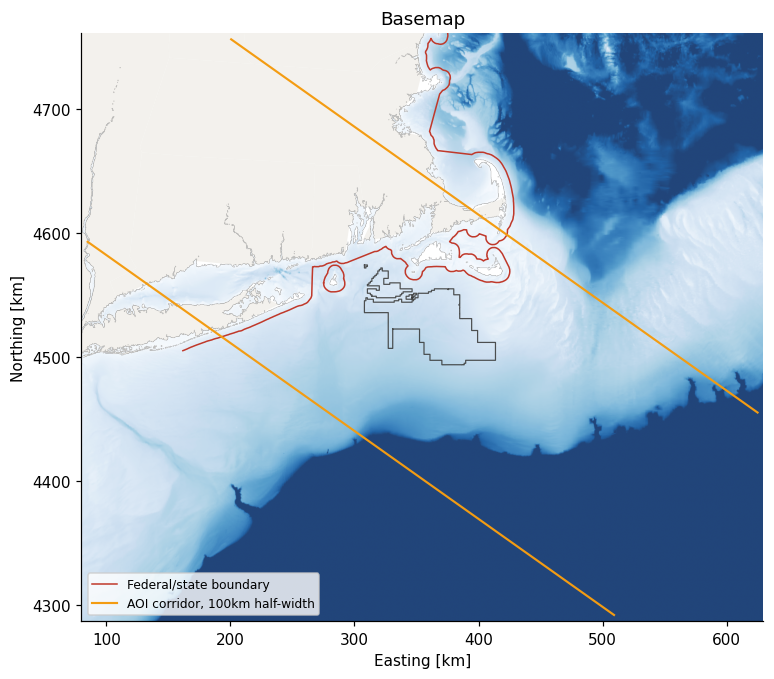

In [17]:
fig, ax = new_ax()
ax.set_xlim(EXTENT_KM[0], EXTENT_KM[1]); ax.set_ylim(EXTENT_KM[2], EXTENT_KM[3])
draw_land(ax)
ax.imshow(depth_grid_masked, origin="lower", extent=EXTENT_KM, cmap="Blues", vmax=200, alpha=0.9, zorder=1)
for i, line in enumerate(sla_lines_utm):
    ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="#c0392b", linewidth=1.0, zorder=2,
            label="Federal/state boundary" if i == 0 else None)
draw_cluster_outline(ax, cluster.BOUNDARY_NAMES)
draw_aoi_corridor(ax, label=f"AOI corridor, {layout.RADIUS_KM:.0f}km half-width")
ax.legend(fontsize=8, loc="lower left")
ax.set_title("Basemap")
plt.show()

### Eligibility Mask

The generation of speculative farms follows spatial criteria. The model starts from an eligibility grid, a mask, built from conditions like federal waters (NOAA, 2024), water depth under 60 meters (a limit known in the literature as the economic cutoff for monopile fixed-bottom turbines, Musial, 2023), a 100 km distance from the center of the `self` farm being evaluated, and a corridor-style cut formed by two parallel lines that limits the mask by closing `self` off at a distance downwind and upwind along the coast, as noted by Sara C. Pryor and Rebecca J. Barthelmie (Barthelmie et al., 2023), whose work shows that "wakes can extend up to 90 km downwind of the largest lease areas," with the frequency-weighted average wake footprint reaching roughly 2.6 times the lease area itself, and the exclusion of areas already assigned to the committed cluster. The permanent part of the eligibility mask is kept separate from the scenario-dependent part, which makes it easier to apply different rules to Scenario 1 and Scenario 2.

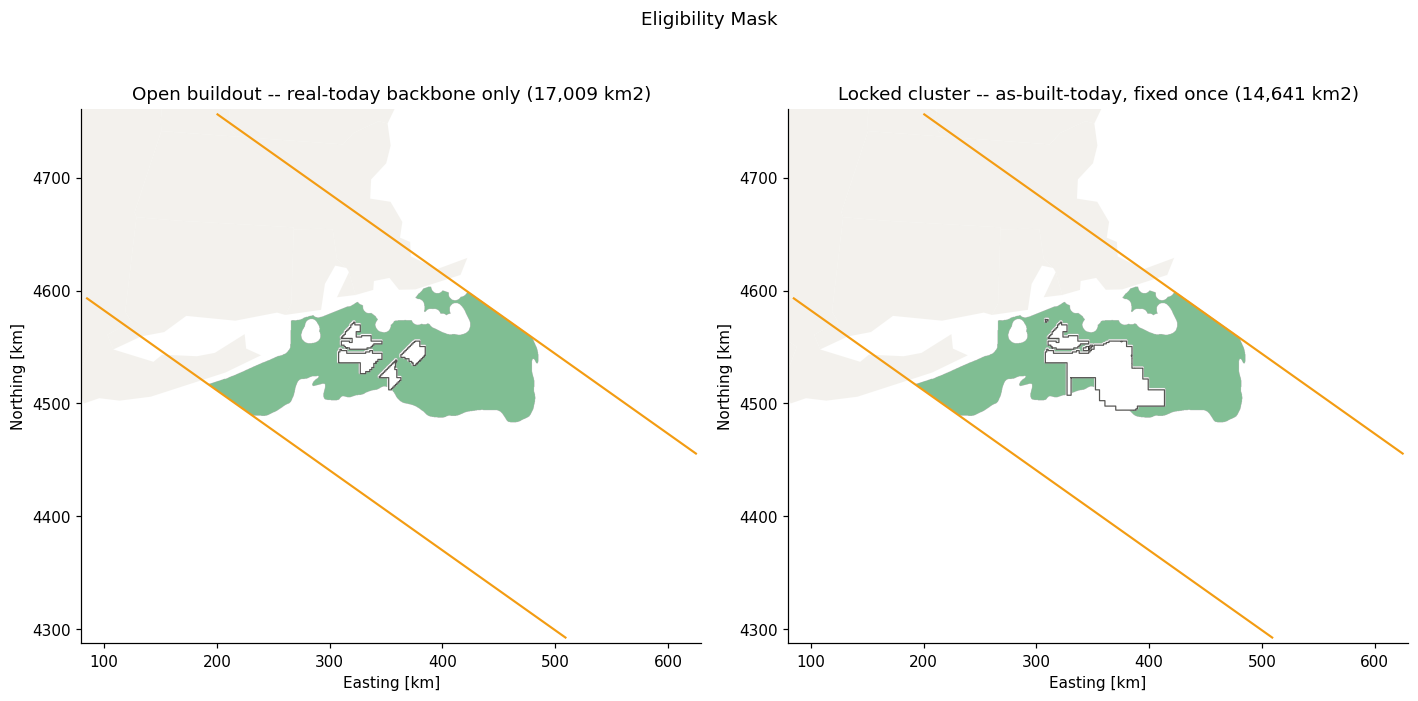

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.6))
for ax, scen_key in zip(axes, ["scenario_1", "scenario_2"]):
    scen = scenarios.SCENARIOS[scen_key]
    eligible = layout.eligible_for(scen)
    ax.set_aspect("equal")
    ax.set_xlabel("Easting [km]"); ax.set_ylabel("Northing [km]")
    ax.set_xlim(EXTENT_KM[0], EXTENT_KM[1]); ax.set_ylim(EXTENT_KM[2], EXTENT_KM[3])
    draw_land(ax)
    eligible_show = np.ma.masked_where(~eligible, eligible)
    ax.imshow(eligible_show, origin="lower", extent=EXTENT_KM, cmap="Greens", vmin=0, vmax=1.4, alpha=0.6, zorder=2)
    draw_cluster_outline(ax, scen.fixed_farm_names)  # ONLY this scenario's fixed farms, not all 13
    draw_aoi_corridor(ax)
    area_km2 = eligible.sum() * (res / 1000) ** 2
    ax.set_title(f"{scen.label} ({area_km2:,.0f} km2)")
fig.suptitle("Eligibility Mask")
plt.tight_layout()
plt.show()

### Mosaic Parcels

The geometry of the new farms is created as a mosaic, where the algorithm divides the available area into plausible parcels, avoiding overlaps and enforcing separation between areas. This way, speculative expansion is not represented as an arbitrary set of squares or isolated points, but as a spatially organized development, compatible with the eligible area of the mask that was built. This was made possible by combining two algorithms commonly used in unrelated fields like landscaping (Passolt et al., 2013) and solid mechanics: Poisson disk (Bridson, 2007), which generates points with a minimum and maximum diameter based on real lease-area sizes in the MA/RI region, filling the whole mask; and Voronoi (Aurenhammer, 1991), which expands each of those points into the mask space in a kind of area "dispute," producing fragments that look like a mosaic, not just visually, but physically feasible as an area for a fixed-bottom wind farm.

In [19]:
rng = np.random.default_rng(SEED)
eligible_s1 = layout.eligible_for(scenarios.SCENARIO_1)
t0 = time.time()
mosaic_out = mosaic.generate_mosaic(eligible_s1, x0, y0, res, layout.R_MIN_M, layout.R_MAX_M, rng,
                                     buffer_cells=layout.BUFFER_CELLS)
print(f"{len(mosaic_out['polygons'])} candidate parcels ({time.time() - t0:.1f}s), "
      f"r=[{layout.R_MIN_M / 1000:.1f},{layout.R_MAX_M / 1000:.1f}]km")

40 candidate parcels (0.5s), r=[4.2,13.6]km


In [20]:
all(p.is_valid for p in mosaic_out['polygons'].values() if not p.is_empty)

True

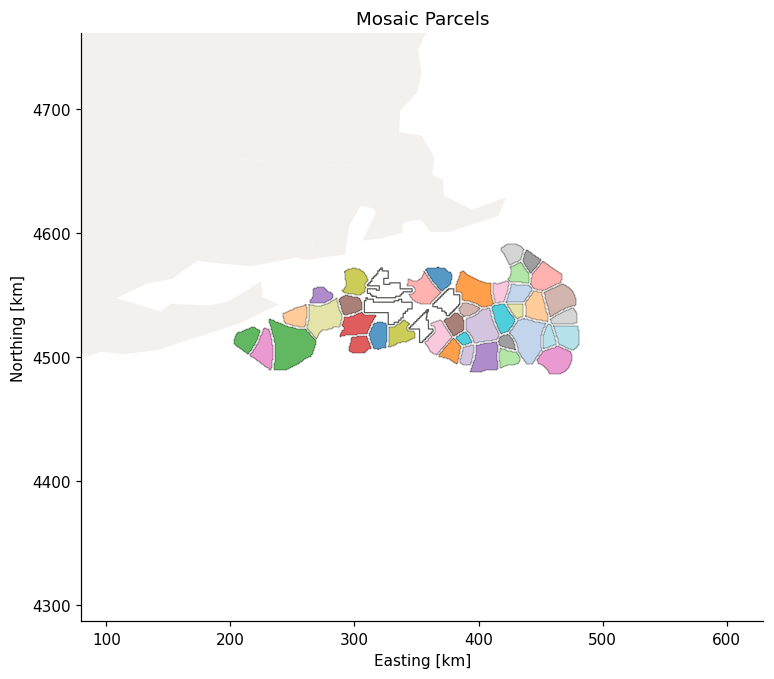

In [21]:
cmap_cat = plt.colormaps["tab20"]
fig, ax = new_ax()
ax.set_xlim(EXTENT_KM[0], EXTENT_KM[1]); ax.set_ylim(EXTENT_KM[2], EXTENT_KM[3])
draw_land(ax)
for pid, poly in mosaic_out["polygons"].items():
    if poly.is_empty:
        continue
    bx, by = poly.exterior.xy
    ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color=cmap_cat(pid % 20), alpha=0.75,
            edgecolor="black", linewidth=0.3)
draw_cluster_outline(ax, scenarios.SCENARIO_1.fixed_farm_names)
ax.set_title("Mosaic Parcels")
plt.show()

## Time, Technology, and Climate

After defining which farms can exist, the pipeline still needs to decide when they arrive and how they get built.

### Arrival Process

Future farms don't enter operation at a constant rate. The model uses an accelerating arrival distribution, so the early years have fewer new projects and the years closer to 2050 concentrate a larger share of the build-out. This choice represents an accelerating offshore growth trajectory.

The cumulative function used is:

$$F(t) = \frac{\exp(\gamma t) - 1}{\exp(\gamma T) - 1}$$

with gamma = 0.12 and a 24-year horizon. The code draws arrival years for the infill farms and for the speculative farms separately; the two calendars are independent and only meet when the whole system is evaluated.

In [22]:
t = np.linspace(0, timeline.T, 300)
rate = settings.TIMELINE_GAMMA * np.exp(settings.TIMELINE_GAMMA * t) / (np.exp(settings.TIMELINE_GAMMA * timeline.T) - 1)

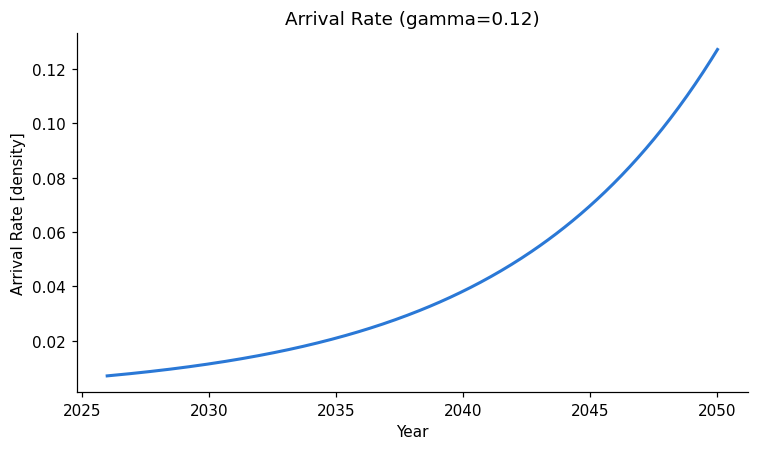

In [23]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(settings.YEAR_START + t, rate, color="#2a78d6", linewidth=2)
ax.set_xlabel("Year")
ax.set_ylabel("Arrival Rate [density]")
ax.set_title(f"Arrival Rate (gamma={settings.TIMELINE_GAMMA})")
fig.tight_layout()
plt.show()

### Turbine Catalog & Technology Transition

Next, every farm that doesn't already have a real technology defined gets a turbine from the catalog. The catalog follows the WindIO ontology, and includes 11, 13, and 15.5 MW models built as objects based on existing IEA reference models, plus 18 and 22 MW models created with PyWake's Generic Wind Turbine object, to cover the possibilities of a 25-year horizon.

The logistic transition over the 25 years is modeled as a sigmoid normalized with Softmax, for each turbine model $i$ in year $t$:

$$P_i(t) = \frac{\exp(k_i (t - t_{0,i}))}{\sum_j \exp(k_j (t - t_{0,j}))}$$

Where:
- $t_{0,i}$ is the central year of commercial maturity for turbine $i$.
- $k_i$ is the penetration rate (the slope of the transition curve).
- $\sum_i P_i(t) = 1.0$, guaranteeing that the probabilities always sum to one in the sampled year.

In [24]:
years = np.linspace(settings.YEAR_START, settings.YEAR_END, 200)
share_matrix = np.array([turbines.shares(y) for y in years])
turbine_labels = [f"{name} ({turbines.diameter(name):.0f}m)" for name in turbines.NAMES]

/var/folders/1j/_3qt8y3s02n_m1mtt8pcvnh00000gr/T/ipykernel_99288/466736816.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.stackplot(years, share_matrix.T, labels=turbine_labels, colors=cm.get_cmap("viridis")(np.linspace(0.15, 0.9, len(turbines.NAMES))))


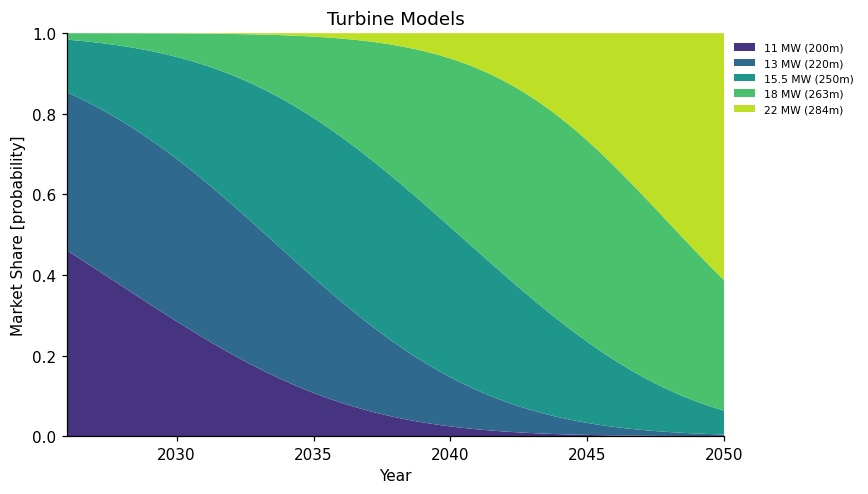

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.stackplot(years, share_matrix.T, labels=turbine_labels, colors=cm.get_cmap("viridis")(np.linspace(0.15, 0.9, len(turbines.NAMES))))
ax.set_xlim(years.min(), years.max())
ax.set_ylim(0, 1)
ax.set_xlabel("Year")
ax.set_ylabel("Market Share [probability]")
ax.set_title("Turbine Models")
ax.legend(loc="upper left", fontsize=7, ncol=1, frameon=False, bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()
plt.show()

### Power Density

After the turbine model for the speculative farm is chosen, the power density of speculative farms, in MW/km2, defines how each eligible area gets converted into installed capacity, turbine count, and, as a result, wake-interaction potential. The choice was informed by an analysis of 17 North American offshore projects gathered in an NREL study (McCoy et al., 2024), where observed values ranged between 2 and 9 MW/km2, with very high densities appearing as less frequent cases and a larger concentration between 2 and 5. That evidence was translated into a triangular distribution, bounded by the observed minimum and maximum, with a mode at 4 MW/km2: this choice concentrates draws around a representative density while keeping a right tail for denser, rarer projects. In each Monte Carlo realization, the sampled density is combined with the available area and the chosen turbine to define the capacity added by each speculative farm. The algorithm then fills the scenario's world progressively until it reaches the capacity target set for the batch, 30 GW, an optimistic figure from the same NREL study, letting different combinations of geometry, technology, and density reach the same target while producing different turbine counts and different wake-loss patterns.

In [26]:
def run_fill(scenario):
    rng = np.random.default_rng(SEED)
    cluster_farms = [orchestrator._tile(f) for f in cluster.generate_cluster(rng, scenario)]
    fixed_mw = sum(len(f["x"]) * aep._rated_mw(f["turbine"]) for f in cluster_farms)
    farms = layout.generate_scenario(rng, scenario, fixed_capacity_mw=fixed_mw)
    cum_mw = np.cumsum([len(f["x"]) * turbines.rated_mw(f["turbine"]) for f in farms])
    density = np.array([(len(f["x"]) * turbines.rated_mw(f["turbine"])) / (f["polygon"].area / 1e6) for f in farms])
    return farms, cum_mw, density, fixed_mw


speculative_s1, cum_mw_s1, density_s1, fixed_mw_s1 = run_fill(scenarios.SCENARIO_1)
speculative_s2, cum_mw_s2, density_s2, fixed_mw_s2 = run_fill(scenarios.SCENARIO_2)
for label, fixed_mw, spec_farms, cum_mw in [("scenario_1", fixed_mw_s1, speculative_s1, cum_mw_s1),
                                             ("scenario_2", fixed_mw_s2, speculative_s2, cum_mw_s2)]:
    total_gw = (fixed_mw + cum_mw[-1]) / 1000
    print(f"{label}: fixed={fixed_mw / 1000:.2f}GW + speculative={cum_mw[-1] / 1000:.2f}GW "
          f"({len(spec_farms)} farms) = total={total_gw:.2f}GW (target {settings.SPECULATIVE_TARGET_MW / 1000:.0f}GW)")

scenario_1: fixed=3.50GW + speculative=27.08GW (23 farms) = total=30.59GW (target 30GW)
scenario_2: fixed=13.45GW + speculative=17.14GW (14 farms) = total=30.59GW (target 30GW)


In [27]:
len(speculative_s1), len(speculative_s2)

(23, 14)

### Real-World Reference

In [28]:
real_projects = [
    ("Revolution Wind", 2.10), ("South Fork Wind", 2.40), ("Sunrise Wind 1", 2.63),
    ("Bay State Wind", 2.64), ("Vineyard Wind 1", 3.03), ("Ocean Wind 2", 3.34),
    ("Ocean Wind 1", 3.59), ("SouthCoast Wind", 3.88), ("Beacon Wind", 4.66),
    ("New England", 4.95), ("US Wind", 5.20), ("Atlantic Shores South 1", 5.32),
    ("CVOW-C", 5.67), ("Kitty Hawk", 7.07), ("Empire Wind 1", 7.42),
    ("Empire Wind 2", 8.13), ("Skipjack", 9.03),
]
real_projects = sorted(real_projects, key=lambda p: p[1])
names = [p[0] for p in real_projects]
values = [p[1] for p in real_projects]

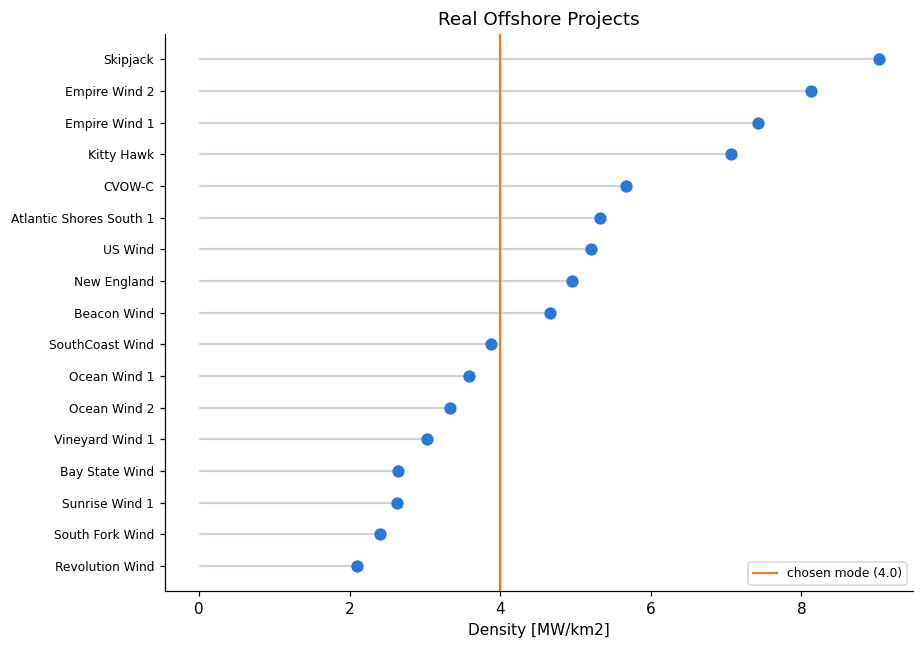

In [29]:
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.hlines(range(len(values)), 0, values, color="#c9d6e3", linewidth=1.5, zorder=1)
ax.scatter(values, range(len(values)), color="#2a78d6", s=50, zorder=2)
ax.axvline(4.0, color="#e67e22", linewidth=1.5, label="chosen mode (4.0)")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("Density [MW/km2]")
ax.set_title("Real Offshore Projects")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

### Density Distribution

In [30]:
rng_d = np.random.default_rng(123)
lo, mode, hi = settings.RHO_TARGET_TRIANGULAR
target_density = rng_d.triangular(lo, mode, hi, size=20000)
xlim = (lo - 0.3, hi + 0.3)
bins = np.linspace(xlim[0], xlim[1], 40)

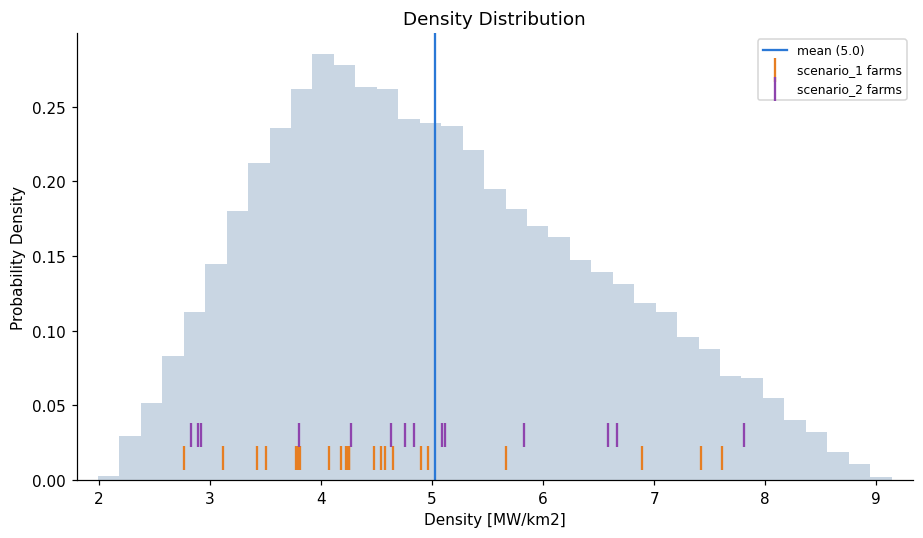

In [31]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(target_density, bins=bins, color="#c9d6e3", density=True)
ax.axvline(target_density.mean(), color="#2a78d6", linewidth=1.5, label=f"mean ({target_density.mean():.1f})")

y_tick = ax.get_ylim()[1] * 0.05
ax.scatter(density_s1, np.full(len(density_s1), y_tick), marker="|", s=250, color="#e67e22", label="scenario_1 farms")
ax.scatter(density_s2, np.full(len(density_s2), 2 * y_tick), marker="|", s=250, color="#8e44ad", label="scenario_2 farms")

ax.set_xlim(*xlim)
ax.set_xlabel("Density [MW/km2]")
ax.set_ylabel("Probability Density")
ax.set_title("Density Distribution")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Resulting Worlds

In [32]:
cmap_time = plt.colormaps["plasma"]
norm_year = lambda y: (y - settings.YEAR_START) / (settings.YEAR_END - settings.YEAR_START)


def plot_world(ax, farms, scenario, title):
    ax.set_aspect("equal")
    ax.set_xlabel("Easting [km]"); ax.set_ylabel("Northing [km]")
    ax.set_xlim(EXTENT_KM[0], EXTENT_KM[1]); ax.set_ylim(EXTENT_KM[2], EXTENT_KM[3])
    draw_land(ax)
    for f in farms:
        poly = f["polygon"]
        bx, by = poly.exterior.xy
        ax.fill(np.array(bx) / 1000, np.array(by) / 1000, color=cmap_time(norm_year(f["arrival_year"])),
                alpha=0.85, edgecolor="black", linewidth=0.4)
    draw_cluster_outline(ax, scenario.fixed_farm_names)
    ax.set_title(title)

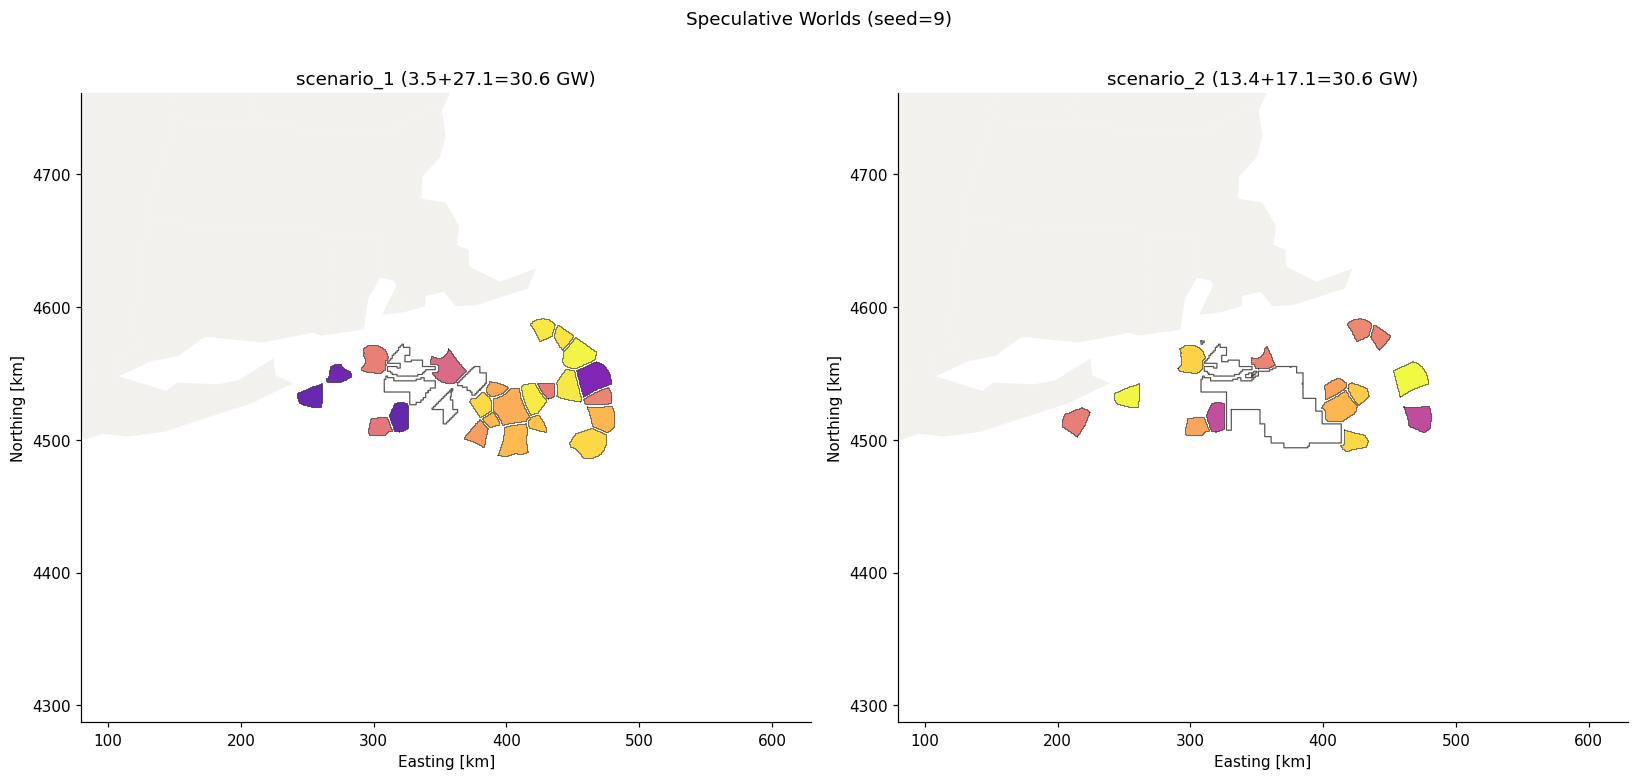

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7.2))
plot_world(axes[0], speculative_s1, scenarios.SCENARIO_1,
           f"scenario_1 ({fixed_mw_s1 / 1000:.1f}+{cum_mw_s1[-1] / 1000:.1f}={(fixed_mw_s1 + cum_mw_s1[-1]) / 1000:.1f} GW)")
plot_world(axes[1], speculative_s2, scenarios.SCENARIO_2,
           f"scenario_2 ({fixed_mw_s2 / 1000:.1f}+{cum_mw_s2[-1] / 1000:.1f}={(fixed_mw_s2 + cum_mw_s2[-1]) / 1000:.1f} GW)")
fig.suptitle(f"Speculative Worlds (seed={SEED})")
fig.tight_layout()
plt.show()

### Capacity Over Time

In [34]:
def total_cum_by_year(farms, fixed_mw):
    by_year = sorted(zip([f["arrival_year"] for f in farms],
                          [len(f["x"]) * turbines.rated_mw(f["turbine"]) for f in farms]))
    years = [settings.YEAR_START] + [y for y, _ in by_year]
    cum = np.concatenate([[fixed_mw], fixed_mw + np.cumsum([mw for _, mw in by_year])])
    return years, cum / 1000

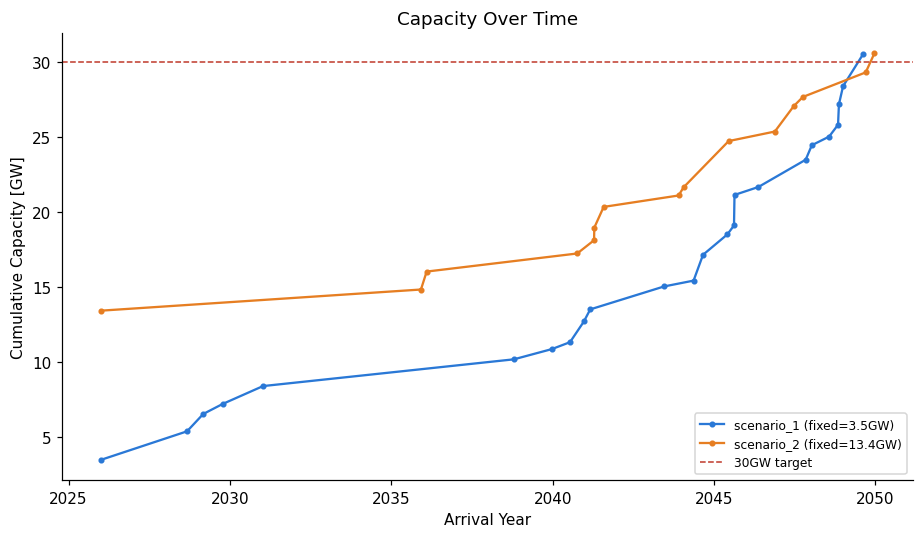

In [35]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for farms, fixed_mw, label, color in [(speculative_s1, fixed_mw_s1, "scenario_1", "#2a78d6"),
                                       (speculative_s2, fixed_mw_s2, "scenario_2", "#e67e22")]:
    years, cum = total_cum_by_year(farms, fixed_mw)
    ax.plot(years, cum, marker="o", markersize=3, label=f"{label} (fixed={fixed_mw / 1000:.1f}GW)", color=color)
ax.axhline(settings.SPECULATIVE_TARGET_MW / 1000, color="#c0392b", linestyle="--", linewidth=1, label="30GW target")
ax.set_xlabel("Arrival Year")
ax.set_ylabel("Cumulative Capacity [GW]")
ax.set_title("Capacity Over Time")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Populated Worlds

In [36]:
COLOR_BASELINE = "#b0b0b0"


def full_scenario_turbines(scenario, speculative_farms):
    rng = np.random.default_rng(SEED)
    cluster_farms = [orchestrator._tile(f) for f in cluster.generate_cluster(rng, scenario)]
    return cluster_farms + speculative_farms  # speculative_farms already tiled by layout.generate_scenario


all_s1 = full_scenario_turbines(scenarios.SCENARIO_1, speculative_s1)
all_s2 = full_scenario_turbines(scenarios.SCENARIO_2, speculative_s2)

In [37]:
len(all_s1), len(all_s2)

(28, 27)

In [38]:
def plot_turbines(ax, farms, scenario, title):
    ax.set_aspect("equal")
    ax.set_xlabel("Easting [km]"); ax.set_ylabel("Northing [km]")
    ax.set_xlim(EXTENT_KM[0], EXTENT_KM[1]); ax.set_ylim(EXTENT_KM[2], EXTENT_KM[3])
    draw_land(ax)
    n_wtg = 0
    for f in farms:
        c = COLOR_BASELINE if f["arrival_year"] <= settings.YEAR_START else cmap_time(norm_year(f["arrival_year"]))
        fx, fy = np.asarray(f["x"]), np.asarray(f["y"])  # real-layout farms carry plain lists, not arrays
        ax.scatter(fx / 1000, fy / 1000, s=2.5, color=c, alpha=0.6, linewidth=0)
        n_wtg += len(fx)
    draw_cluster_outline(ax, scenario.fixed_farm_names)
    draw_aoi_corridor(ax)
    ax.set_title(f"{title} ({n_wtg} turbines)")

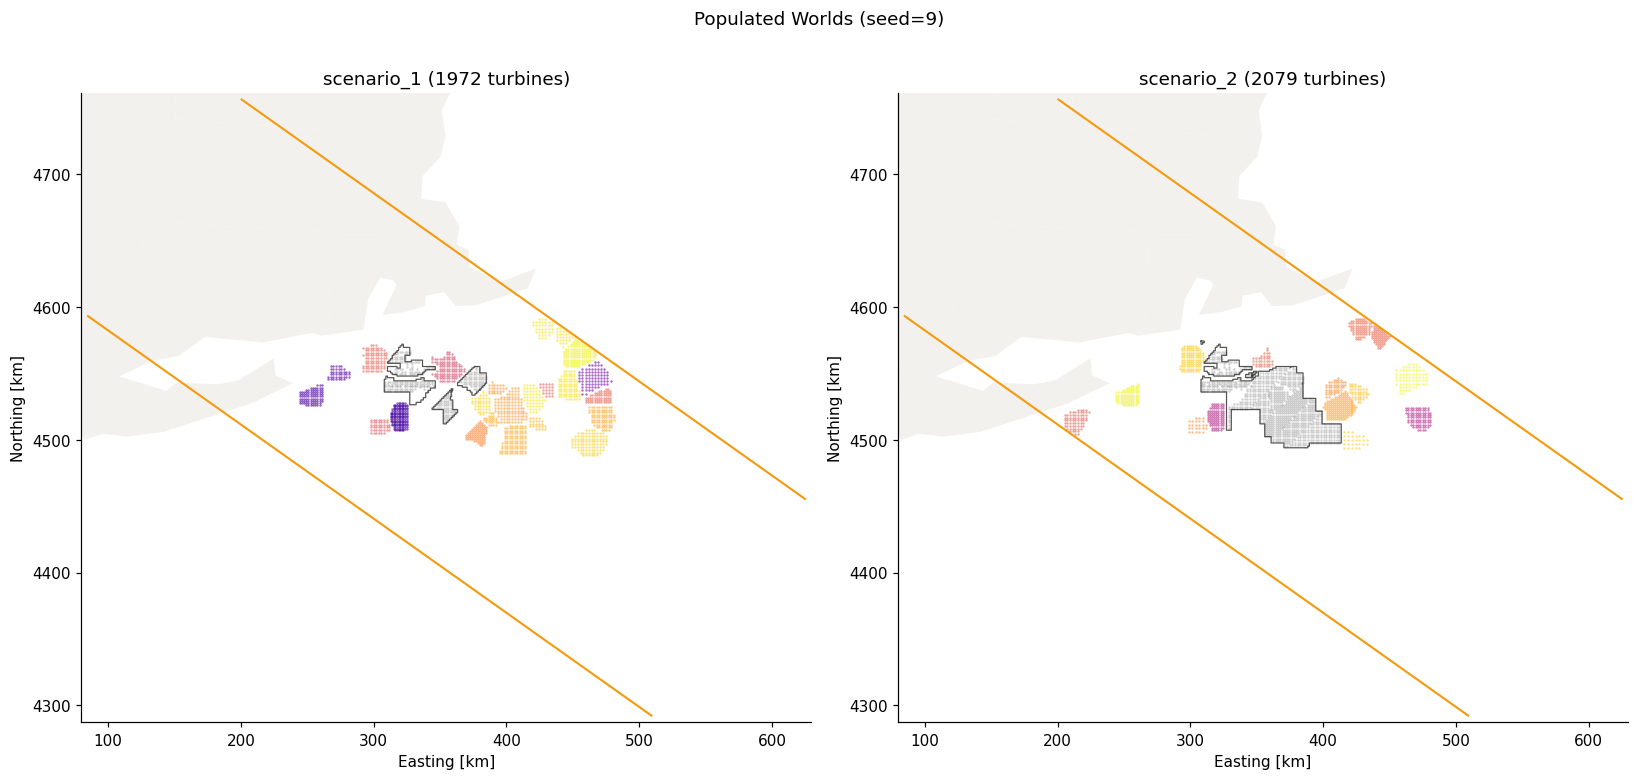

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7.2))
plot_turbines(axes[0], all_s1, scenarios.SCENARIO_1, "scenario_1")
plot_turbines(axes[1], all_s2, scenarios.SCENARIO_2, "scenario_2")
fig.suptitle(f"Populated Worlds (seed={SEED})")
fig.tight_layout()
plt.show()

### Spacing & Capacity

In [40]:
def farm_stats(farms):
    spacing = np.array([f["spacing_d"] for f in farms])
    capacity_gw = np.sort([len(f["x"]) * turbines.rated_mw(f["turbine"]) for f in farms])[::-1] / 1000
    return spacing, capacity_gw


spacing_s1, capacity_s1 = farm_stats(speculative_s1)
spacing_s2, capacity_s2 = farm_stats(speculative_s2)

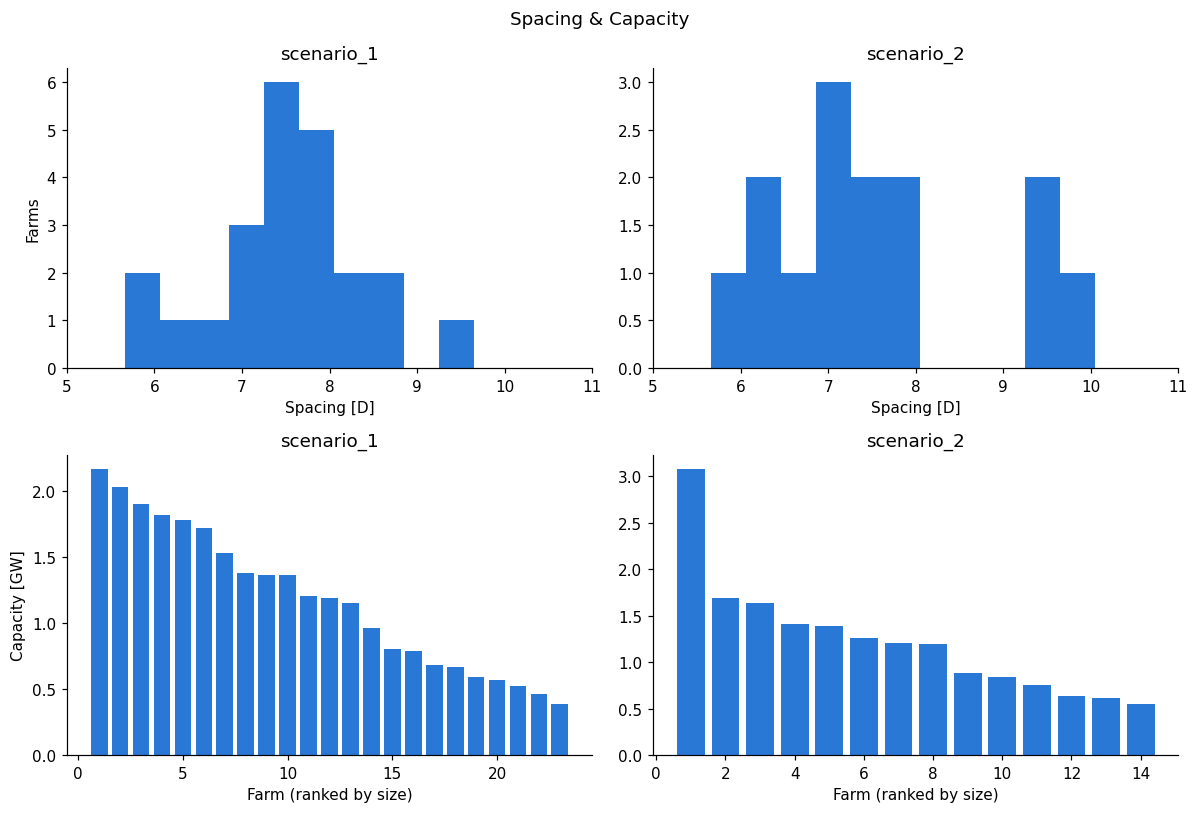

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))

# same bins and ticks on both panels, so scenario_1 and scenario_2 are comparable
spacing_all = np.concatenate([spacing_s1, spacing_s2])
bin_edges = np.linspace(spacing_all.min(), spacing_all.max(), 12)
xticks = np.arange(np.floor(spacing_all.min()), np.ceil(spacing_all.max()) + 1, 1.0)

for ax, spacing, label in zip(axes[0], [spacing_s1, spacing_s2], ["scenario_1", "scenario_2"]):
    ax.hist(spacing, bins=bin_edges, color="#2a78d6")
    ax.set_xticks(xticks)
    ax.set_title(label)
    ax.set_xlabel("Spacing [D]")
axes[0, 0].set_ylabel("Farms")

for ax, capacity, label in zip(axes[1], [capacity_s1, capacity_s2], ["scenario_1", "scenario_2"]):
    ax.bar(range(1, len(capacity) + 1), capacity, color="#2a78d6")  # 1-based, reads as farm 1 not farm 0
    ax.set_title(label)
    ax.set_xlabel("Farm (ranked by size)")
axes[1, 0].set_ylabel("Capacity [GW]")

fig.suptitle("Spacing & Capacity")
fig.tight_layout()
plt.show()

### Wind Climate

Wind climate is treated as an uncertainty shared by the whole `trial`. The model starts from a mean wind rose, built from 24 years of ERA5 data (Hersbach et al., 2020), between 2000 and 2023 (the full analysis is detailed in a separate notebook by Gabriel Negrelli). Direction is described by a mixture of five von Mises distributions, while speed is represented by Weibull distributions fit per 30 degree sector, across 12 sectors.

The current version of the pipeline reduces climate uncertainty to three physically interpretable controls:

- A joint rotation of the wind rose
- A shared multiplier for the speed level
- A shared multiplier for the directional spread

These controls are calibrated with a block-by-year bootstrap. In other words, the variation ranges are not picked by hand, they're measured from the variability observed when the historical years are resampled. For each `trial`, the model draws one climate realization inside those empirically observed limits. Rotation has an estimated standard deviation of 1.48 degrees, the speed multiplier has a standard deviation of 0.005, and the spread multiplier has a standard deviation of 0.026.

It quantifies the uncertainty of estimating the long-term mean climate from the historical sample, it is not, by itself, a full climate-change scenario through 2050.

In [42]:
def rose_freq(mus, kappas, weights=climate.VM_WEIGHTS):
    dens = np.array([w * climate.vonmises_pdf(climate.SECTOR_RAD, mu, kp)
                      for w, mu, kp in zip(weights, mus, kappas)])
    freq = dens.sum(axis=0)
    return freq / freq.sum()


theta_plot = np.append(climate.SECTOR_RAD, climate.SECTOR_RAD[0])

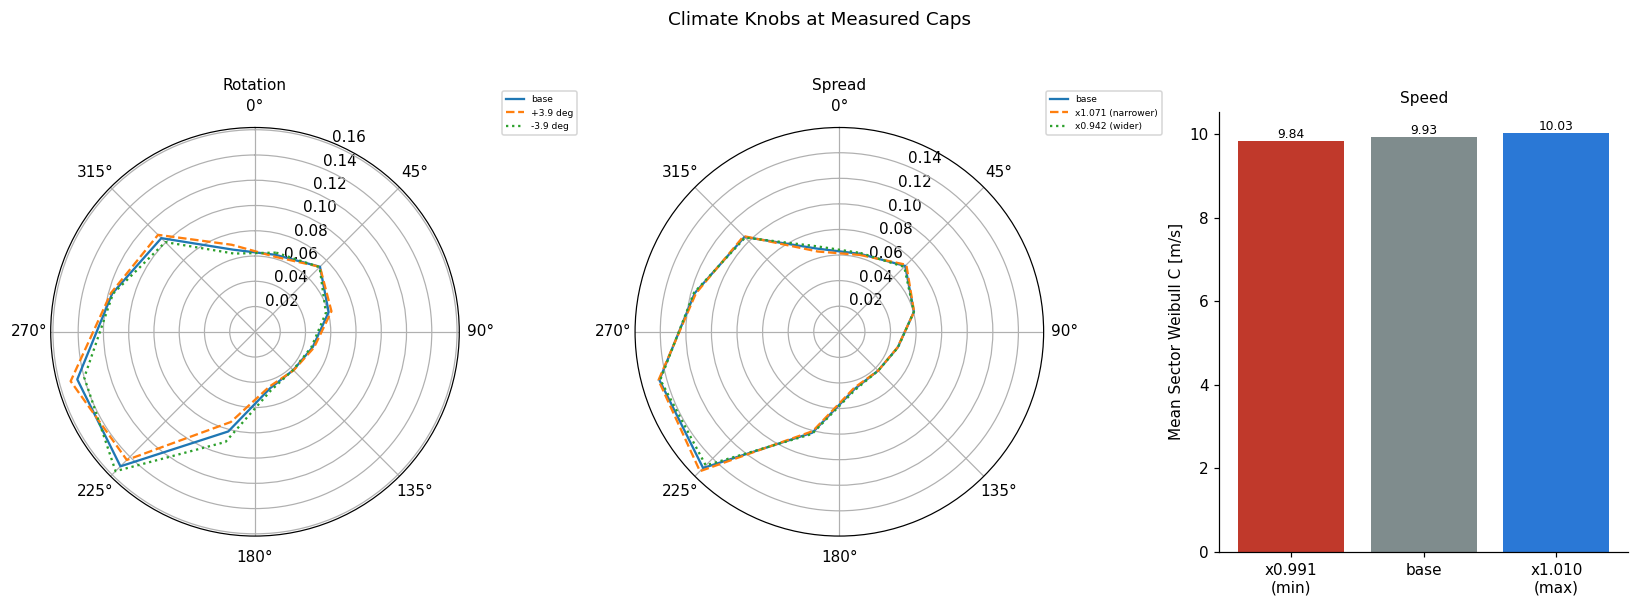

In [43]:
fig = plt.figure(figsize=(15, 5.2))

# rotation
ax1 = fig.add_subplot(1, 3, 1, projection="polar")
for delta_deg, style, label in [(0, "-", "base"),
                                 (climate.ROTATION_MAX_DEG, "--", f"+{climate.ROTATION_MAX_DEG:.1f} deg"),
                                 (-climate.ROTATION_MAX_DEG, ":", f"-{climate.ROTATION_MAX_DEG:.1f} deg")]:
    freq = rose_freq(climate.VM_MUS + np.radians(delta_deg), climate.VM_KAPPAS)
    ax1.plot(theta_plot, np.append(freq, freq[0]), style, label=label)
ax1.set_theta_zero_location("N"); ax1.set_theta_direction(-1)  # meteorological convention: 0=N, clockwise
ax1.set_title("Rotation", fontsize=10)
ax1.legend(fontsize=6, loc="upper right", bbox_to_anchor=(1.3, 1.1))

# spread
ax2 = fig.add_subplot(1, 3, 2, projection="polar")
for mult, style, label in [(1.0, "-", "base"),
                            (climate.SPREAD_RATIO_MAX, "--", f"x{climate.SPREAD_RATIO_MAX:.3f} (narrower)"),
                            (climate.SPREAD_RATIO_MIN, ":", f"x{climate.SPREAD_RATIO_MIN:.3f} (wider)")]:
    freq = rose_freq(climate.VM_MUS, np.clip(climate.VM_KAPPAS * mult, 0.1, 50.0))
    ax2.plot(theta_plot, np.append(freq, freq[0]), style, label=label)
ax2.set_theta_zero_location("N"); ax2.set_theta_direction(-1)
ax2.set_title("Spread", fontsize=10)
ax2.legend(fontsize=6, loc="upper right", bbox_to_anchor=(1.3, 1.1))

# speed, not directional, bar chart of mean sector_C
ax3 = fig.add_subplot(1, 3, 3)
mults = [climate.SPEED_RATIO_MIN, 1.0, climate.SPEED_RATIO_MAX]
labels = [f"x{climate.SPEED_RATIO_MIN:.3f}\n(min)", "base", f"x{climate.SPEED_RATIO_MAX:.3f}\n(max)"]
mean_C = [np.mean(climate.SECTOR_C * m) for m in mults]
ax3.bar(labels, mean_C, color=["#c0392b", "#7f8c8d", "#2a78d6"])
ax3.set_ylabel("Mean Sector Weibull C [m/s]")
ax3.set_title("Speed", fontsize=10)
for i, v in enumerate(mean_C):
    ax3.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Climate Knobs at Measured Caps", y=1.05)
fig.tight_layout()
plt.show()

Knob draw distributions, 2000 draws of each knob, dashed lines mark the hard caps.

In [44]:
rng_c = np.random.default_rng(42)
n_draws = 2000
rotations = [climate.sample_scenario(rng_c)["rotation_deg"] for _ in range(n_draws)]
speeds = [climate.sample_scenario(rng_c)["speed_multiplier"] for _ in range(n_draws)]
spreads = [climate.sample_scenario(rng_c)["spread_multiplier"] for _ in range(n_draws)]

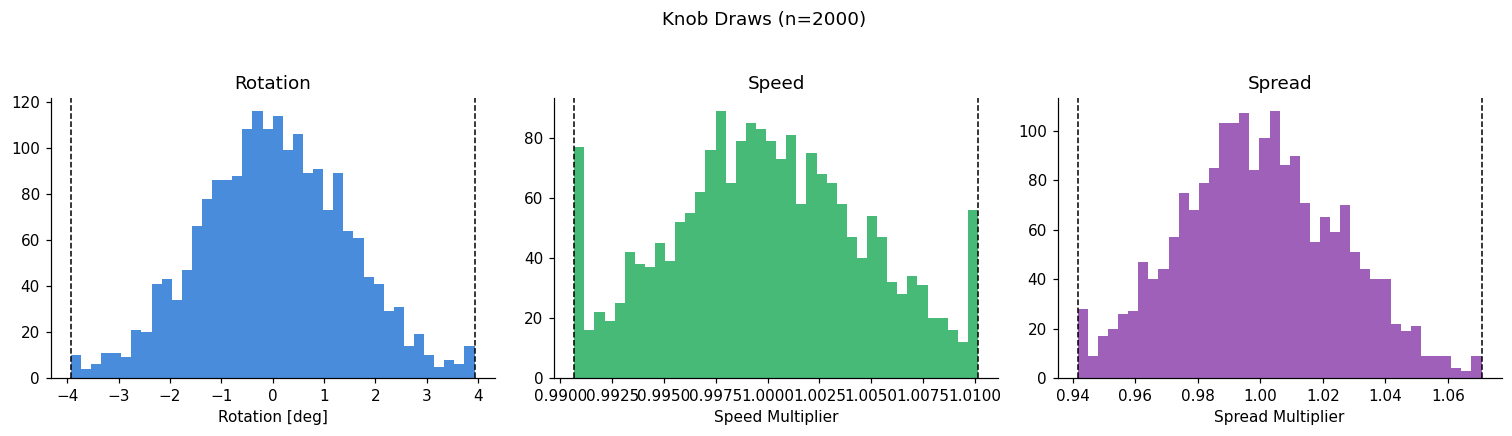

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
specs = [
    (rotations, "Rotation [deg]", [-climate.ROTATION_MAX_DEG, climate.ROTATION_MAX_DEG], "#2a78d6"),
    (speeds, "Speed Multiplier", [climate.SPEED_RATIO_MIN, climate.SPEED_RATIO_MAX], "#27ae60"),
    (spreads, "Spread Multiplier", [climate.SPREAD_RATIO_MIN, climate.SPREAD_RATIO_MAX], "#8e44ad"),
]
for ax, (data, name, caps, color) in zip(axes, specs):
    ax.hist(data, bins=40, color=color, alpha=0.85)
    for c in caps:
        ax.axvline(c, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel(name)
    ax.set_title(name.split(" ")[0])
fig.suptitle(f"Knob Draws (n={n_draws})", y=1.03)
fig.tight_layout()
plt.show()

## How Wake Losses Are Calculated

Once a `trial`'s regional future is defined, the pipeline evaluates wake interactions using PyWake (Pedersen et al., 2023). The calculation is repeated at fixed time checkpoints between 2026 and 2050, typically five years apart.

At each checkpoint, the model checks which farms are already active, and the rule is direct: a farm takes part in the simulation if its arrival year is less than or equal to the start of the segment being evaluated. The active-farm list is rebuilt every period, which keeps the logic explicit and avoids depending on accumulated state between segments.

For each `trial`, two main evaluations are made:

The first is the isolated condition, computed once at the start: the target farm `self` alone, with no neighbors, only its own internal wake effects and that trial's climate conditions.

The second happens per segment: `self` is simulated together with every turbine from the active farms in the cluster and the speculative expansion. `self`'s turbines are placed first in the simulation vector, and their AEP is extracted after the joint calculation.

The difference between isolated AEP and active AEP represents the effect of external wakes on `self`.

The percentage loss can be calculated this way:

$$\text{loss\_pct} = 100 \times \frac{\text{AEP}_{isolated} - \text{AEP}_{active}}{\text{AEP}_{isolated}}$$

The simulation considers 12 wind directions, in 30 degree increments, and 23 speeds, from 3 to 25 m/s. Each evaluation, therefore, covers 276 flow conditions.

A third value records the total AEP of every active turbine, called `world_aep_gwh`, reusing the same joint simulation with no extra cost from a second PyWake call.

In [46]:
logger = Logger()
t0 = time.time()
orchestrator.run_trial(seed=SEED, logger=logger, scenario=scenarios.SCENARIO_1, model_name=wake_models.ACTIVE_MODEL)
elapsed = time.time() - t0
print(f"1 trial, scenario_1, seed={SEED}, model={wake_models.ACTIVE_MODEL}: "
      f"{len(logger.arrivals)} farms, {len(logger.segments)} segments, {elapsed:.1f}s")

1 trial, scenario_1, seed=9, model=supergaussian: 28 farms, 5 segments, 22.3s


In [47]:
segments_df = pd.DataFrame(logger.segments)
segments_df[["segment_id", "start_year", "n_active_farms", "isolated_aep_gwh", "active_aep_gwh",
             "world_aep_gwh", "loss_pct"]]

,segment_id,start_year,n_active_farms,isolated_aep_gwh,active_aep_gwh,world_aep_gwh,loss_pct
0,0,2026,5,3261.692574,3217.235928,14034.125784,1.362993
1,1,2031,8,3261.692574,3182.997506,27617.905406,2.412706
2,2,2036,9,3261.692574,3183.378450,32717.642877,2.401027
3,3,2041,13,3261.692574,3149.638431,49175.314176,3.435460
4,4,2046,20,3261.692574,3118.632586,80280.898481,4.386066


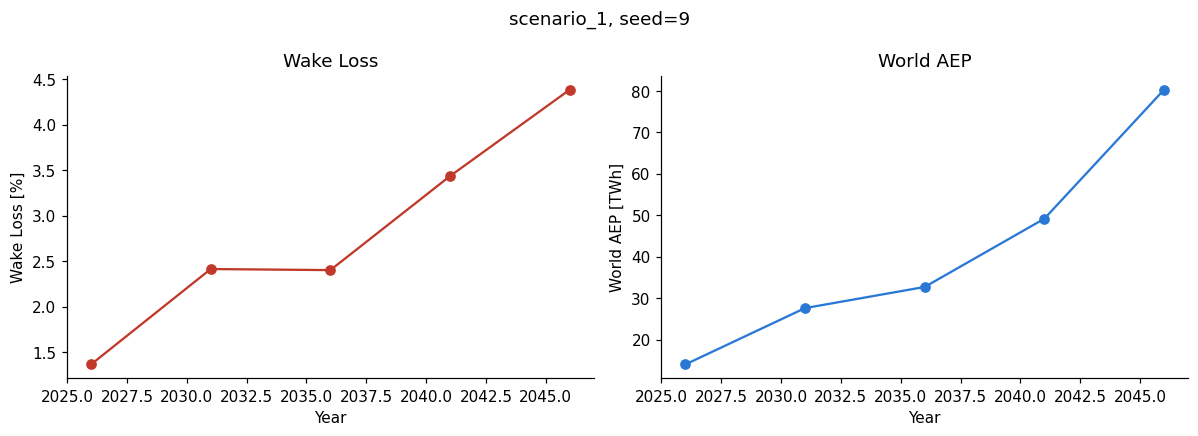

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(segments_df["start_year"], segments_df["loss_pct"], marker="o", color="#c0392b")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Wake Loss [%]")
axes[0].set_title("Wake Loss")
axes[1].plot(segments_df["start_year"], segments_df["world_aep_gwh"] / 1000, marker="o", color="#2a78d6")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("World AEP [TWh]")
axes[1].set_title("World AEP")
fig.suptitle(f"scenario_1, seed={SEED}")
fig.tight_layout()
plt.show()

## What Is Saved, and How?

The current production architecture uses one joint simulation of every active turbine. Other strategies were investigated, including background fields and the external-farm mechanisms available in PyWake's own libraries, but they didn't offer enough accuracy and performance gain to replace the chosen approach.

Each `trial` produces three levels of information, saved as Parquet files, chosen for their smaller size and easier data reading.

The `trials` table records the general features of the sampled future: seed, scenario, number of speculative farms, `self` farm configuration, climate controls, and the wake model chosen.

The `arrivals` table records each farm individually: its source, arrival year, turbine, spacing, and turbine count.

The `segments` table records the system's evolution over time: period, number of active farms and turbines, isolated AEP, active AEP, `self`'s percentage loss, the system's total AEP, and the computational cost of each step.

In [49]:
trials_df = pd.DataFrame(logger.trials)
trials_df

,trial_id,seed,scenario,n_speculative,fixed_capacity_mw,self_turbine,self_spacing_d,wake_model,t_generate_s,t_tile_s,climate_rotation_deg,climate_speed_multiplier,climate_spread_multiplier
0,9,9,scenario_1,23,3502.0,13 MW,8,supergaussian,0.502746,0.000003,-0.578845,1.001031,1.049132


In [50]:
arrivals_df = pd.DataFrame(logger.arrivals)
arrivals_df.head()

,trial_id,farm,source,arrival_year,turbine,spacing_d,n_turbines,rho_target_mw_km2,spacing_clipped
0,9,Vineyard Wind,real_layout,2026.0,Vineyard Wind,NaN,62,NaN,None
1,9,Revolution Wind,real_layout,2026.0,Revolution Wind,NaN,65,NaN,None
2,9,South Fork Wind,real_layout,2026.0,South Fork Wind,NaN,12,NaN,None
3,9,Sunrise Wind South,real_layout,2026.0,Sunrise Wind South,NaN,96,NaN,None
4,9,New England Wind 2 South,self,2026.0,13 MW,8.0,61,NaN,None


In [51]:
arrivals_df["source"].value_counts()

source
speculative    23
real_layout     4
self            1
Name: count, dtype: int64

These records turn every result into an auditable history. If a `trial` shows a high loss, it's possible to check which farms were active, when they arrived, which technology they used, how many turbines were installed, how the wind rose was perturbed, and what the regional density was in that period.

The current pipeline provides the quantitative basis for carrying these uncertainties forward into risk evaluation for design decisions. It builds a temporal distribution of losses and production under alternative futures. The next step can use that distribution to identify robust configurations, evaluate the risk of early decisions, compare expansion scenarios, and, later on, feed this information into a risk-informed optimization framework.

## References

Imported from the project's own `references.bib` (Overleaf, Risk Study, Wind Farms in US paper).

**Wake modeling, AEP & layout optimization under uncertainty**

- Barthelmie, R. J., Larsen, G. C., & Pryor, S. C. (2023). Modeling annual electricity production and levelized cost of energy from the US East Coast offshore wind energy lease areas. *Energies*, 16(12), 4550. [doi:10.3390/en16124550](https://doi.org/10.3390/en16124550)
- Becker, M., & van Wingerden, J.-W. (2026). Risk-averse wake steering optimization for energy and power maximization under uncertain wind direction changes. *Journal of Physics: Conference Series*, 3224(3), 032124. [doi:10.1088/1742-6596/3224/3/032124](https://doi.org/10.1088/1742-6596/3224/3/032124)
- Beiter, P., Mai, T., Mowers, M., & Bistline, J. (2023). Expanded modelling scenarios to understand the role of offshore wind in decarbonizing the United States. *Nature Energy*, 8, 1-10. [doi:10.1038/s41560-023-01364-y](https://doi.org/10.1038/s41560-023-01364-y)
- Bertini, A., Amaripadath, D., Gobbo, E., & Attia, S. (2026). Uncertainty analysis for variables affecting the whole life carbon performance of nearly zero energy residential building renovation. *Energy and Buildings*, 362, 117496. [doi:10.1016/j.enbuild.2026.117496](https://doi.org/10.1016/j.enbuild.2026.117496)
- Blondel, F., & Cathelain, M. (2020). An alternative form of the super-Gaussian wind turbine wake model. *Wind Energy Science*, 5, 1225-1236. [doi:10.5194/wes-5-1225-2020](https://doi.org/10.5194/wes-5-1225-2020)
- Barthelmie, R. J., Dantuono, K. E., Renner, E. J., Letson, F. L., & Pryor, S. C. (2021). Extreme wind and waves in U.S. East Coast offshore wind energy lease areas. *Energies*, 14(4), 1053. [doi:10.3390/en14041053](https://doi.org/10.3390/en14041053)
- Harrison, R. L. (2010). Introduction to Monte Carlo simulation. *AIP Conference Proceedings*, 1204, 17.
- IEA Wind Task 11 (2015). Topical Expert Meeting #82 on Uncertainty Quantification of Wind Farm Flow Models. International Energy Agency (IEA) Wind. [PDF](https://iea-wind.org/wp-content/uploads/2023/10/82_Uncertainty-Quantification-of-WindFarm-Flow-Models.pdf)
- Murcia, J. P., Réthoré, P.-E., Hansen, K. S., Natarajan, A., & Sørensen, J. D. (2015). A new method to estimate the uncertainty of AEP of offshore wind power plants applied to Horns Rev 1. *EWEA Annual Conference and Exhibition 2015*, 161-165.
- McCoy, A., Musial, W., Hammond, R., Mulas Hernando, D., Duffy, P., Beiter, P., Perez, P., Baranowski, R., Reber, G., & Spitsen, P. (2024). Offshore Wind Market Report: 2024 Edition Executive Summary (NREL/TP-5000-90921). National Renewable Energy Laboratory. [doi:10.2172/2434295](https://doi.org/10.2172/2434295)
- Nygaard, N. G. (2014). Wakes in very large wind farms and the effect of neighbouring wind farms. *Journal of Physics: Conference Series*, 524(1), 012162. [doi:10.1088/1742-6596/524/1/012162](https://doi.org/10.1088/1742-6596/524/1/012162)
- Grønnegaard Pedersen, J., Svensson, E., Poulsen, L., & Gayle Nygaard, N. (2022). Turbulence optimized park model with Gaussian wake profile. *Journal of Physics: Conference Series*, 2265, 022063. [doi:10.1088/1742-6596/2265/2/022063](https://doi.org/10.1088/1742-6596/2265/2/022063)
- Pedersen, M. M., Forsting, A. M., van der Laan, P., Riva, R., Roman, L. A. A., Risco, J. C., Friis-Møller, M., Quick, J., Christiansen, J. P. S., Rodrigues, R. V., et al. (2023). PyWake 2.5.0: An open-source wind farm simulation tool. *DTU Wind, Technical University of Denmark*, 960.
- Moura, A. H., & Rodrigues, R. V. (2025). Parametric analysis of inter-farm wake interactions in offshore wind farm projects along the US East Coast. *Journal of Physics: Conference Series*, 3016(1), 012049. [doi:10.1088/1742-6596/3016/1/012049](https://doi.org/10.1088/1742-6596/3016/1/012049)
- Barthelmie, R. J., Thompson, K. B., & Pryor, S. C. (2025). Factors impacting projected annual energy production from offshore wind farms on the US East and West Coasts. *Energies*, 18(15), 4037. [doi:10.3390/en18154037](https://doi.org/10.3390/en18154037)
- Rodrigues, R. V., & Moura, A. H. (2025). Benchmarking engineering wake models for assessing wind farm wakes interaction. *Journal of Physics: Conference Series*, 3016(1), 012045. [doi:10.1088/1742-6596/3016/1/012045](https://doi.org/10.1088/1742-6596/3016/1/012045)
- Rosencrans, D., Lundquist, J., Optis, M., Rybchuk, A., Bodini, N., & Rossol, M. (2023). Annual variability of wake impacts on Mid-Atlantic offshore wind plant deployments. *Wind Energy Science Discussions*. [doi:10.5194/wes-2023-38](https://doi.org/10.5194/wes-2023-38)
- Rosencrans, D., Lundquist, J. K., Optis, M., Rybchuk, A., Bodini, N., & Rossol, M. (2024). Seasonal variability of wake impacts on US mid-Atlantic offshore wind plant power production. *Wind Energy Science*, 9(3), 555-583. [doi:10.5194/wes-9-555-2024](https://doi.org/10.5194/wes-9-555-2024)
- Sinner, M., & Fleming, P. (2024). Robust wind farm layout optimization. *Journal of Physics: Conference Series*, 2767, 032036. [doi:10.1088/1742-6596/2767/3/032036](https://doi.org/10.1088/1742-6596/2767/3/032036)
- Skittides, C., & Fruh, W.-G. (2015). A new Measure-Correlate-Predict wind resource prediction method. *Renewable Energy and Power Quality Journal*, 13.
- Thomas, J., Baker, N., Malisani, P., Quaeghebeur, E., Sanchez Perez-Moreno, S., Jasa, J., Bay, C., Tilli, F., Bieniek, D., Robinson, N., Stanley, A. P. J., Holt, W., & Ning, A. (2023). A comparison of eight optimization methods applied to a wind farm layout optimization problem. *Wind Energy Science*, 8, 865-891. [doi:10.5194/wes-8-865-2023](https://doi.org/10.5194/wes-8-865-2023)
- Wen, Y., Song, M., & Wang, J. (2022). Wind farm layout optimization with uncertain wind condition. *Energy Conversion and Management*, 256, 115347. [doi:10.1016/j.enconman.2022.115347](https://doi.org/10.1016/j.enconman.2022.115347)
- Xue, W., Li, R., Ji, W., Zhai, E., Yang, H., Ning, Q., Hu, X., & Liao, G. (2025). Wind resource assessment offshore Fujian using 30-year wind estimates. *PLOS One*, 20. [doi:10.1371/journal.pone.0326759](https://doi.org/10.1371/journal.pone.0326759)

**Spatial / geometric layout methods (Voronoi & Poisson-disk)**

- Aurenhammer, F. (1991). Voronoi diagrams, a survey of a fundamental geometric data structure. *ACM Computing Surveys*, 23(3), 345-405. [doi:10.1145/116873.116880](https://doi.org/10.1145/116873.116880)
- Bridson, R. (2007). Fast Poisson disk sampling in arbitrary dimensions. *ACM SIGGRAPH*. [doi:10.1145/1278780.1278807](https://doi.org/10.1145/1278780.1278807)
- Passolt, G., Fix, M. J., & Toth, S. F. (2013). A Voronoi tessellation based approach to generate hypothetical forest landscapes. *Canadian Journal of Forest Research*, 43(11), 1057-1066. [doi:10.1139/cjfr-2012-0265](https://doi.org/10.1139/cjfr-2012-0265)

**Wind & climate reanalysis data**

- Hersbach, H., Bell, B., Berrisford, P., Hirahara, S., Horányi, A., Muñoz-Sabater, J., Nicolas, J., Peubey, C., Radu, R., Schepers, D., et al. (2020). The ERA5 global reanalysis. *Quarterly Journal of the Royal Meteorological Society*, 146(730), 1999-2049. [doi:10.1002/qj.3803](https://doi.org/10.1002/qj.3803)
- Ramon, J., Lledó, L., Torralba, V., Soret, A., & Doblas-Reyes, F. J. (2019). What global reanalysis best represents near-surface winds? *Quarterly Journal of the Royal Meteorological Society*, 145(724), 3236-3251. [doi:10.1002/qj.3616](https://doi.org/10.1002/qj.3616)

**Risk management & insurance**

- Macías-Amador, E., de la Torre-Castro, L., & Kaczenski, J. (2025). Risk assessment model for offshore wind farm decommissioning: analysis of system uncertainty, risk events, and weather delays. [doi:10.5194/wes-2025-195](https://doi.org/10.5194/wes-2025-195)
- Descartes Underwriting (2026). Parametric wind power volatility insurance. [descartesunderwriting.com](https://descartesunderwriting.com/solutions/wind)
- International Organization for Standardization (2018). ISO 31000:2018, risk management: guidelines. [iso.org/standard/65694.html](https://www.iso.org/standard/65694.html)
- Perez, L., Lohbeck, A., & Sarkar, S. (2016). Protection against wind resource volatility. Swiss Reinsurance Company Ltd. [PDF](https://www.swissre.com/dam/jcr:4cf88867-9e90-4f69-b0f4-250ea329b8bf/protection-against-resource-volatility.pdf)
- Watson, S. C. L., Szostek, C. L., Edwards-Jones, A., Wills, B., Watson, G. J., & Beaumont, N. J. (2025). Assessing, monitoring and mitigating the effects of offshore wind farms on biodiversity. *Nature Reviews Biodiversity*. [doi:10.1038/s44358-025-00074-5](https://doi.org/10.1038/s44358-025-00074-5)

**BOEM / NOAA / NREL official data sources**

- Bureau of Ocean Energy Management (2024a). Commercial leases OCS-A 0520, 0521, and 0522. [boem.gov](https://www.boem.gov/renewable-energy/state-activities/commercial-leases-ocs-0520-0521-and-0522)
- Bureau of Ocean Energy Management (2024b). BOEM renewable energy GIS data, map viewer. [boem.maps.arcgis.com](https://boem.maps.arcgis.com/apps/mapviewer/index.html)
- National Oceanic and Atmospheric Administration (2024). U.S. maritime limits and boundaries. [nauticalcharts.noaa.gov](https://nauticalcharts.noaa.gov/data/us-maritime-limits-and-boundaries.html)
- Musial, W. (2023). Floating offshore wind technology. National Renewable Energy Laboratory. [PDF](https://www.boem.gov/sites/default/files/documents/renewable-energy/state-activities/Musial-Floating-Wind-Technology.pdf)
- Fuchs, R., Zuckerman, G., Duffy, P., Shields, M., Musial, W., Beiter, P., Cooperman, A., & Bredenkamp, S. (2024). The cost of offshore wind energy in the United States from 2025 to 2050. [doi:10.2172/2433785](https://doi.org/10.2172/2433785)